# Forget

In [1]:
import os
os.chdir("/data/weiren/Interkcat/Figure")

--- 数据集基础信息 ---
总数据量: 34140

Value (Kcat) 描述性统计:
count    3.414000e+04
mean     1.753778e+03
std      4.964025e+04
min      1.570000e-07
25%      3.357500e-01
50%      3.800000e+00
75%      3.300000e+01
max      5.000000e+06
Name: Value, dtype: float64


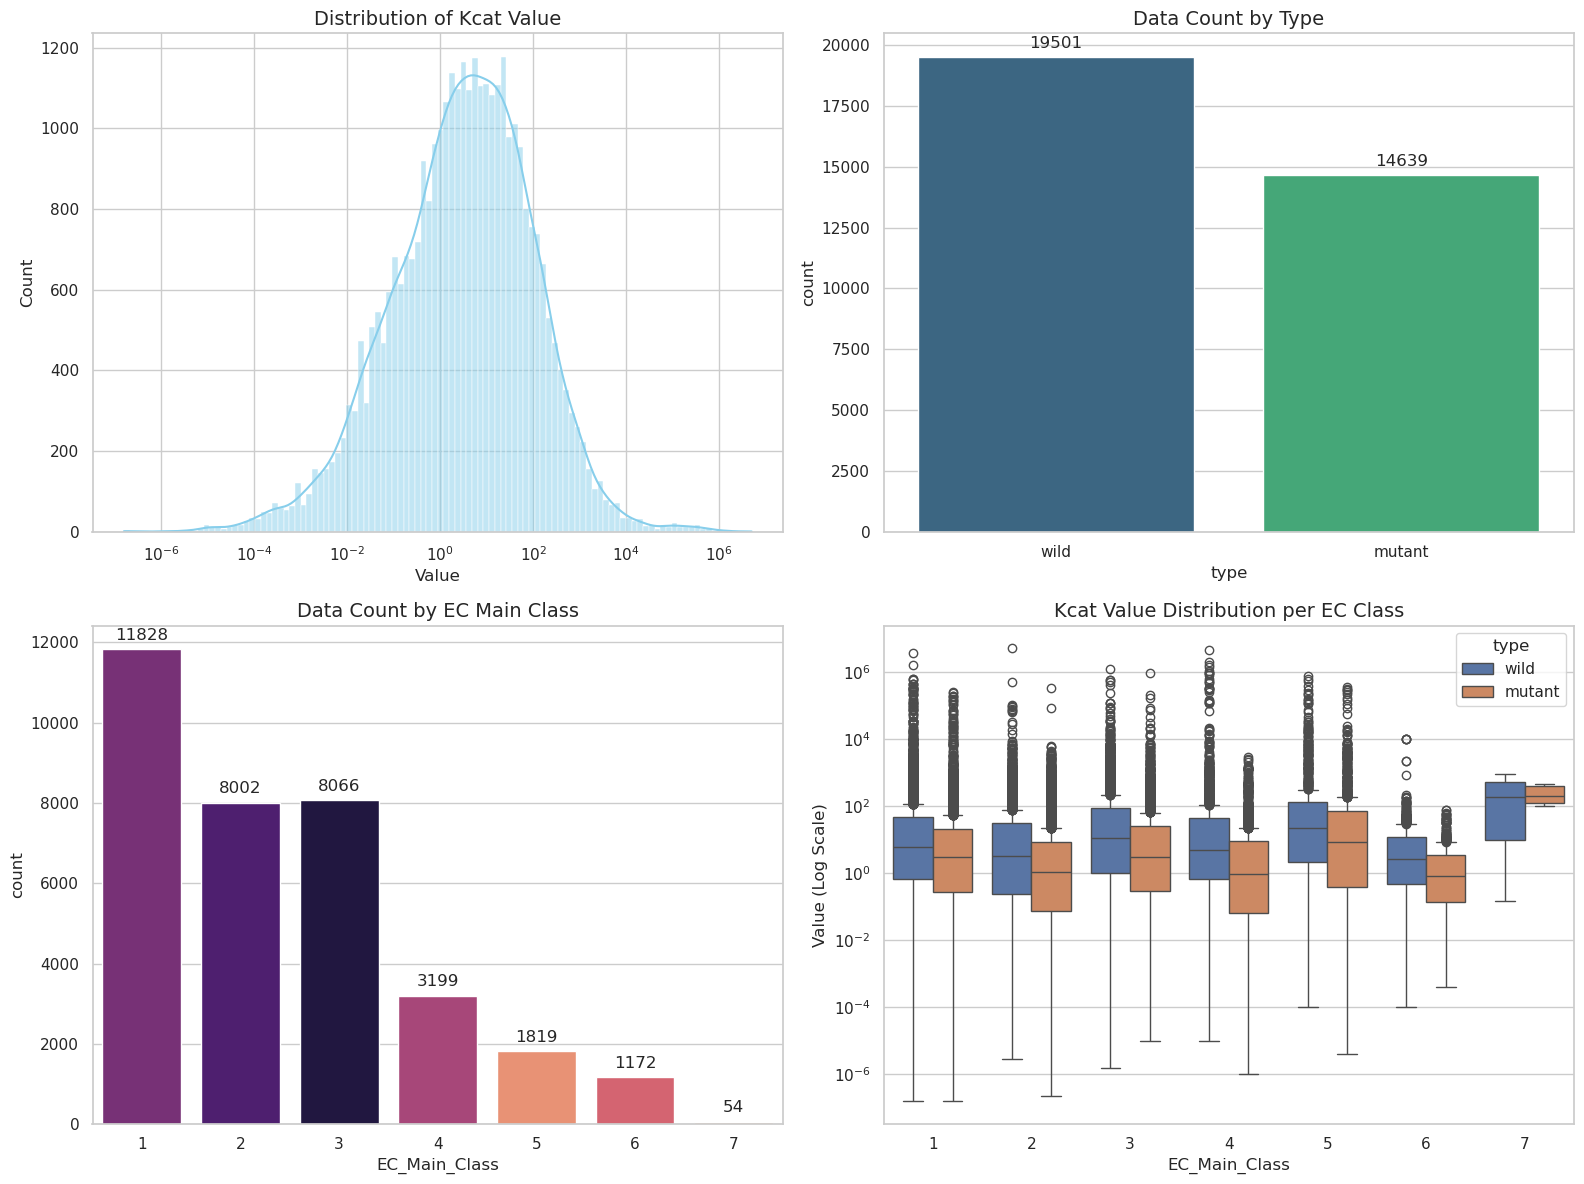


--- 类别与数据类型交叉统计表 ---
type           mutant  wild
EC_Main_Class              
1                4730  7098
2                4014  3988
3                2639  5427
4                1737  1462
5                1002   817
6                 497   675
7                  20    34


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 加载数据
df = pd.read_csv('./Interkcat/EITLEM_KCAT.csv')

# 2. 数据预处理
# 提取 EC Number 的第一位，并转换为整数/字符串进行排序
df['EC_Main_Class'] = df['ECNumber'].astype(str).str[0]

# 3. 基础统计信息打印
print("--- 数据集基础信息 ---")
print(f"总数据量: {len(df)}")
print("\nValue (Kcat) 描述性统计:")
print(df['Value'].describe())

# 设置绘图风格，解决字体缺失问题
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'sans-serif'] 
plt.rcParams['axes.unicode_minus'] = False 

# 创建一个多图画布
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- 图 1: Value (Kcat) 的对数分布图 ---
# 酶活数据通常呈长尾分布，对数化后更符合正态分布特征
sns.histplot(df['Value'], kde=True, ax=axes[0, 0], log_scale=True, color='skyblue')
axes[0, 0].set_title('Distribution of Kcat Value', fontsize=14)
axes[0, 0].set_xlabel('Value')

# --- 图 2: 不同 Type 的数量统计 ---
# 修复 FutureWarning: 分配 x 到 hue 并设置 legend=False
ax2 = sns.countplot(data=df, x='type', hue='type', ax=axes[0, 1], palette='viridis', legend=False)
axes[0, 1].set_title('Data Count by Type', fontsize=14)
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# --- 图 3: EC Main Class (第一位) 的数量分布 ---
ec_order = sorted(df['EC_Main_Class'].unique())
ax3 = sns.countplot(data=df, x='EC_Main_Class', hue='EC_Main_Class', order=ec_order, 
                    ax=axes[1, 0], palette='magma', legend=False)
axes[1, 0].set_title('Data Count by EC Main Class', fontsize=14)
for p in ax3.patches:
    ax3.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# --- 图 4: 不同 EC 分类下的 Kcat 值分布 (Boxplot) ---
# 这里换成箱线图能更好地观察不同 EC 类别的 Kcat 差异
sns.boxplot(data=df, x='EC_Main_Class', y='Value', hue='type', order=ec_order, ax=axes[1, 1])
axes[1, 1].set_yscale('log') # 纵轴采用对数坐标
axes[1, 1].set_title('Kcat Value Distribution per EC Class', fontsize=14)
axes[1, 1].set_ylabel('Value (Log Scale)')

plt.tight_layout()
plt.show()

# 4. 输出各类别的具体数值矩阵
print("\n--- 类别与数据类型交叉统计表 ---")
summary_table = pd.crosstab(df['EC_Main_Class'], df['type'])
print(summary_table)

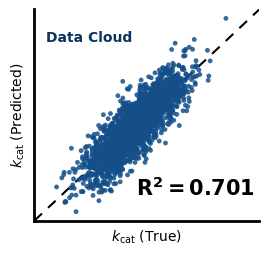

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

# ---------------------------------------------------------
# 1. 全局字体与样式设置 (符合SCI顶刊规范)
# ---------------------------------------------------------
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'
plt.rcParams['axes.linewidth'] = 2.0  # 坐标轴线宽

# ---------------------------------------------------------
# 2. 生成模拟数据 (R^2 约为 0.701 的椭圆数据云)
# ---------------------------------------------------------
np.random.seed(42)
n_points = 2500
x_true = np.random.normal(loc=10, scale=2.5, size=n_points)
# 添加噪声以控制R^2，使得形状呈现为纺锤形/椭圆形数据云
noise = np.random.normal(loc=0, scale=1.6, size=n_points)
y_pred = x_true + noise

# 计算实际的坐标轴范围，方便后续画对角线和对齐文本
min_val = min(x_true.min(), y_pred.min()) - 1
max_val = max(x_true.max(), y_pred.max()) + 1

# ---------------------------------------------------------
# 3. 创建画布 (控制比例和背景色)
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(3, 3.25))

# ---------------------------------------------------------
# 4. 绘制数据点与理想对角线
# ---------------------------------------------------------
# 绘制对角线 (y=x)
ax.plot([min_val, max_val], [min_val, max_val], 
        color='black', linestyle='--', linewidth=1.5, dashes=(5, 4), zorder=1)

# 绘制散点 (深蓝色，适当的透明度和边缘以防止重叠模糊)
ax.scatter(x_true, y_pred, 
           color='#144f8a', s=12, alpha=0.85, edgecolors='none', zorder=2)

# ---------------------------------------------------------
# 5. 坐标轴格式化
# ---------------------------------------------------------
# 设置轴的范围，让起点严格对齐对角线
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

# 隐藏上方和右方的边框线
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 隐藏所有刻度和刻度标签 (概念图保持纯净)
ax.set_xticks([])
ax.set_yticks([])

# 6. 添加文本与标签
ax.set_xlabel(r'$\it{k}_{\mathrm{cat}}$ (True)', fontsize=10, labelpad=5)
ax.set_ylabel(r'$\it{k}_{\mathrm{cat}}$ (Predicted)', fontsize=10, labelpad=5)

ax.text(min_val + 0.05*(max_val-min_val), max_val - 0.15*(max_val-min_val), 
        'Data Cloud', fontsize=10, color='#0a3360', fontweight='bold')

ax.text(max_val - 0.02*(max_val-min_val), min_val + 0.1*(max_val-min_val), 
        r'$\mathbf{R^2 = 0.701}$', fontsize=15, ha='right', va='bottom', color='black')

plt.subplots_adjust(left=0.15, right=0.9, top=0.85, bottom=0.2)
plt.savefig('TOC_Graphic_1.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

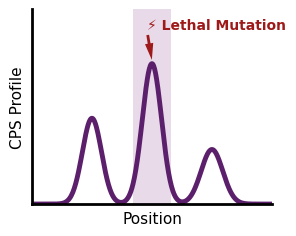

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. 全局字体与样式设置 (符合SCI规范)
# ---------------------------------------------------------
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 2.0  # 坐标轴线宽保持粗细适中

# ---------------------------------------------------------
# 2. 数据生成 (使用三个高斯分布叠加模拟平滑曲线)
# ---------------------------------------------------------
x = np.linspace(0, 100, 500)

def gaussian(x, amplitude, mean, stddev):
    return amplitude * np.exp(-((x - mean)**2) / (2 * stddev**2))

# 模拟三个峰：左侧中等峰，中间最高峰，右侧小峰
y = gaussian(x, 0.55, 25, 4.0) + gaussian(x, 0.9, 50, 4.0) + gaussian(x, 0.35, 75, 4.5)

# 3. 创建画布
fig, ax = plt.subplots(figsize=(3, 3))

# ---------------------------------------------------------
# 4. 绘制核心图像元素
# ---------------------------------------------------------
# 绘制核心高亮阴影区域 (包裹最高的峰)
# zorder=1 将其置于底层，避免遮挡曲线
ax.axvspan(42, 58, facecolor='#e3d1e3', alpha=0.8, zorder=1)

# 绘制多峰曲线 (深紫色)
ax.plot(x, y, color='#5c1f6b', linewidth=3.5, zorder=2)

# ---------------------------------------------------------
# 5. 坐标轴格式化
# ---------------------------------------------------------
# 隐藏上方和右方的边框线，保留L型坐标轴
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 隐藏所有刻度线和刻度标签 (保持概念图的纯净度)
ax.set_xticks([])
ax.set_yticks([])

# 设置轴的显示范围
ax.set_xlim(0, 100)
ax.set_ylim(0, 1.25)  # 顶部留白，为箭头和文字提供空间

# ---------------------------------------------------------
# 6. 添加文本、箭头与标签
# ---------------------------------------------------------
# Y轴标签
ax.set_ylabel('CPS Profile', fontsize=11, labelpad=5)
ax.set_xlabel('Position', fontsize=11, labelpad=5)


# 红色突变标注与箭头 (结合Unicode闪电符号⚡)
# xy为箭头尖端位置，xytext为文本位置
ax.annotate('⚡ Lethal Mutation', 
            xy=(50, 0.92), 
            xytext=(48, 1.15),
            arrowprops=dict(facecolor='#9e1a1a', edgecolor='none', shrink=0.02, width=2, headwidth=6),
            fontsize=10, color='#9e1a1a', fontweight='bold', va='center', ha='left', zorder=3)

# ---------------------------------------------------------
# 7. 调整布局与导出
# ---------------------------------------------------------
plt.subplots_adjust(left=0.15, right=0.95, top=0.85, bottom=0.2)
plt.savefig('TOC_Graphic_2.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

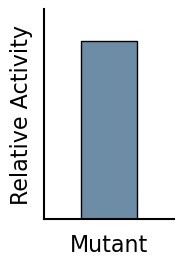

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches
from matplotlib.path import Path

# =========================================================
# 1. 全局 SCI 风格设置 (Arial/Helvetica 无衬线字体)
# =========================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 1.5

# =========================================================
# Figure 2: 单独绘制右侧柱状图 (Relative Activity)
# =========================================================
# 创建 2x3 英寸垂直画布（更窄以适应单个柱子）
fig2, ax2 = plt.subplots(figsize=(2, 3))

# -- 绘制单个柱子 --
prot_color = '#6d8da6'
ax2.bar([0], [0.85], color=prot_color, width=0.6, edgecolor='black', linewidth=1.0)
ax2.set_xlim(-0.7, 0.7) # 调整 X轴范围使柱子居中且不被截断
ax2.set_ylim(0, 1) # Y轴留白以保持极简感

# -- 坐标轴格式化 (极简 L 型) --
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_xticks([0]) # 隐藏除了柱子位置外的刻度线
ax2.set_yticks([]) # 隐藏 Y轴刻度线和值

# X轴标签 (在柱子下方)
ax2.set_xticklabels(['Mutant'], fontsize=16)
# 移除 X轴上的小短线，让它看起来更干净
ax2.tick_params(axis='x', length=0, pad=10) 

# Y轴标签 (使用清晰的无衬线字体)
ax2.set_ylabel('Relative Activity', fontsize=16, labelpad=8)

# 调整布局以防止文本被截断
plt.subplots_adjust(left=0.25, right=0.9, top=0.9, bottom=0.2)
plt.savefig('TOC_Graphic_3.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show() # 如果只需要文件，可以注释掉这行

/tmp/ipykernel_444604/4194427286.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Test_R2', data=df_melted, ax=ax,


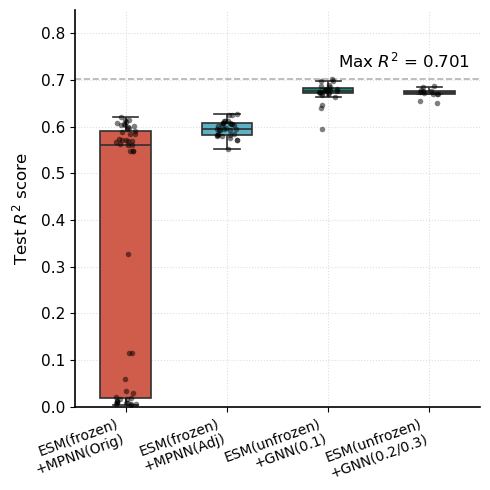

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,        
    'ytick.labelsize': 11,
    'axes.linewidth': 1.2
})

file_path = "./Interkcat/hyperparameters.xlsx"
try:
    df_hyper = pd.read_excel(file_path, header=2)
except:
    df_hyper = pd.read_csv("hyperparameters.xlsx - Sheet1.csv", header=2)

group1 = pd.to_numeric(df_hyper['TEST_R2'].dropna(), errors='coerce').dropna()
group2 = pd.to_numeric(df_hyper['TEST_R2.1'].dropna(), errors='coerce').dropna()
group3 = pd.to_numeric(df_hyper[df_hyper['Dropout_rate'] == 0.1]['TEST_R2.2'].dropna(), errors='coerce').dropna()
group4 = pd.to_numeric(df_hyper[df_hyper['Dropout_rate.1'].isin([0.2, 0.3])]['TEST_R2.3'].dropna(), errors='coerce').dropna()

data = []
labels = ['ESM(frozen)\n+MPNN(Orig)', 'ESM(frozen)\n+MPNN(Adj)', 'ESM(unfrozen)\n+GNN(0.1)', 'ESM(unfrozen)\n+GNN(0.2/0.3)']

for val in group1: data.append({'Group': labels[0], 'Test_R2': val})
for val in group2: data.append({'Group': labels[1], 'Test_R2': val})
for val in group3: data.append({'Group': labels[2], 'Test_R2': val})
for val in group4: data.append({'Group': labels[3], 'Test_R2': val})
df_melted = pd.DataFrame(data)

fig, ax = plt.subplots(figsize=(5, 5))

colors = ['#E64B35', '#4DBBD5', '#00A087', '#3C5488']

sns.boxplot(x='Group', y='Test_R2', data=df_melted, ax=ax,
            palette=colors, width=0.5, linewidth=1.2, fliersize=0)

sns.stripplot(x='Group', y='Test_R2', data=df_melted, ax=ax,

              color='black', alpha=0.5, size=4, jitter=True)

ax.set_xlabel('')
ax.set_ylabel('Test $R^2$ score', labelpad=8)
ax.set_ylim(0.0, 0.85)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(True, linestyle=':', alpha=0.4) 

plt.xticks(rotation=20, ha='right')
max_r2 = df_melted['Test_R2'].max()

ax.axhline(y=max_r2, color='gray', linestyle='--', alpha=0.6, linewidth=1.2)

ax.text(x=3.4, y=max_r2 + 0.02, s=f'Max $R^2$ = {max_r2:.3f}',

        va='bottom', ha='right', fontsize=12, color='black')

plt.tight_layout()
plt.savefig('./Interkcat/Figure/F3_A.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

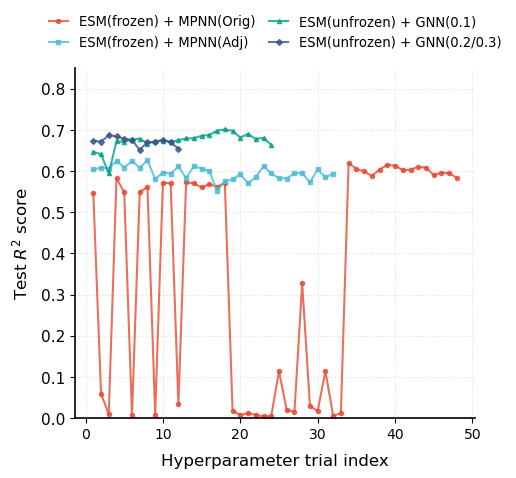

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,         
    'ytick.labelsize': 11,
    'axes.linewidth': 1.2,
    'lines.linewidth': 1.5,
})

file_path = "./Interkcat/hyperparameters.xlsx"
try:
    df_hyper = pd.read_excel(file_path, header=2) 
except:
    df_hyper = pd.read_csv("hyperparameters.xlsx - Sheet1.csv", header=2)

group1 = pd.to_numeric(df_hyper['TEST_R2'].dropna(), errors='coerce').dropna()
group2 = pd.to_numeric(df_hyper['TEST_R2.1'].dropna(), errors='coerce').dropna()
group3 = pd.to_numeric(df_hyper[df_hyper['Dropout_rate'] == 0.1]['TEST_R2.2'].dropna(), errors='coerce').dropna()
group4 = pd.to_numeric(df_hyper[df_hyper['Dropout_rate.1'].isin([0.2, 0.3])]['TEST_R2.3'].dropna(), errors='coerce').dropna()

fig, ax = plt.subplots(figsize=(5, 5))
colors = ['#E64B35', '#4DBBD5', '#00A087', '#3C5488']
markers = ['o', 's', '^', 'D']
labels = ['ESM(frozen) + MPNN(Orig)', 
          'ESM(frozen) + MPNN(Adj)', 
          'ESM(unfrozen) + GNN(0.1)', 
          'ESM(unfrozen) + GNN(0.2/0.3)']

for i, g in enumerate([group1, group2, group3, group4]):
    ax.plot(range(1, len(g)+1), g, marker=markers[i], markersize=3, 
            linestyle='-', color=colors[i], alpha=0.8, label=labels[i])

ax.set_xlabel('Hyperparameter trial index', labelpad=8)
ax.set_ylabel('Test $R^2$ score', labelpad=8)
ax.set_ylim(0.0, 0.85)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(True, linestyle=':', alpha=0.4) 

# ==========================================
# 关键修改区域：优化图例布局，防止重叠
# ==========================================
# 将图例移至图表正上方 (bbox_to_anchor=(0.5, 1.02))
# 使用 ncol=2 分两列，并稍微缩小字体和列间距(columnspacing)以适应画布宽度
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), 
          frameon=False, fontsize=9.5, ncol=2, 
          handlelength=1.5, columnspacing=1.0)

# 使用 subplots_adjust 替代 tight_layout，防止外部图例被裁剪
plt.subplots_adjust(top=0.85, bottom=0.15, left=0.15, right=0.95)

# 保存图片，bbox_inches='tight' 会自动将外部的图例包裹进最终生成的图片中
plt.savefig('./Interkcat/Figure/F3_B.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

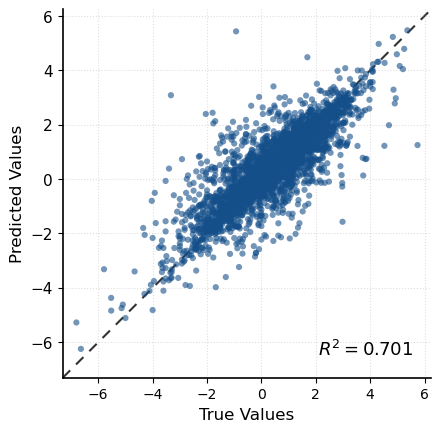

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# =========================================================
# 1. 全局 SCI 顶刊排版样式设置
# =========================================================
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.labelsize': 12,          # 轴标签字号 (单图适度加大)
    'xtick.labelsize': 10,         
    'ytick.labelsize': 11,
    'axes.linewidth': 1.2,         # 边框加粗
})

# =========================================================
# 2. 读取与预处理数据
# =========================================================
# 尝试读取数据 (兼容您的文件夹路径和直接读取)
file_path = "./Interkcat/model_test_performance.csv"
try:
    df_perf = pd.read_csv(file_path)
except FileNotFoundError:
    df_perf = pd.read_csv("model_test_performance.csv")

all_val_preds = df_perf['Predicted']
all_val_targets = df_perf['Actual']

# 计算真实数据的 R2 分数
r2 = r2_score(all_val_targets, all_val_preds)

# =========================================================
# 3. 创建画布并绘图
# =========================================================
# 散点对比图最佳比例为严格的正方形，这里设定 4.5 x 4.5 英寸
fig, ax = plt.subplots(figsize=(4.5, 4.5))

# 绘制散点图 (使用经典的深蓝科研色，增加透明度呈现点云密度)
ax.scatter(all_val_targets, all_val_preds, 
           s=20, c='#144f8a', alpha=0.6, edgecolors='none', zorder=2)

# =========================================================
# 4. 坐标轴、对角线与细节格式化
# =========================================================
# 计算坐标轴的上下限，稍微留一点缓冲空间
lims = [
    min(all_val_preds.min(), all_val_targets.min()) - 0.5,
    max(all_val_preds.max(), all_val_targets.max()) + 0.5
]

# 绘制完美的 Y=X 理想预测对角线 (置于底层 zorder=1)
ax.plot(lims, lims, color='black', linestyle='--', linewidth=1.5, 
        dashes=(5, 4), alpha=0.8, zorder=1)

# 【核心】强制XY轴物理刻度比例为 1:1，保证对角线是严格的 45 度角
ax.set_aspect('equal')
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel('True Values')
ax.set_ylabel('Predicted Values')

# 隐藏上方和右侧的边框线
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(True, linestyle=':', alpha=0.4) 

# =========================================================
# 5. 添加 R2 分数标注
# =========================================================
# 将 R2 文本标注在右下角空白处，使用 \mathbf 实现粗体数学渲染
ax.text(0.95, 0.05, rf'${{R^2 = {r2:.3f}}}$', transform=ax.transAxes, 
        fontsize=13, va='bottom', ha='right', color='black')

# =========================================================
# 6. 调整布局与导出
# =========================================================
plt.tight_layout()
plt.savefig('./Interkcat/Figure/F3_C.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

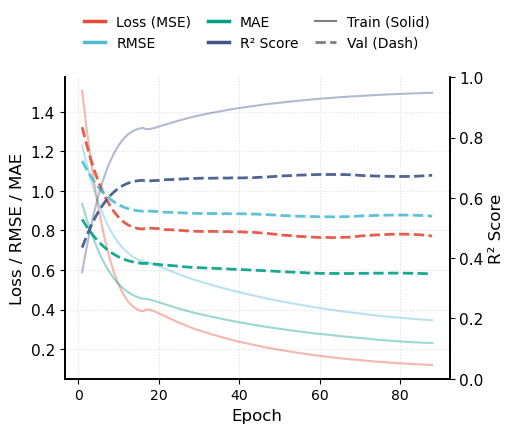

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.signal import savgol_filter

plt.style.use('default')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,         
    'ytick.labelsize': 11,
    'axes.linewidth': 1.2,
})

file_path = "./Interkcat/training_metrics.csv"
try:
    df_train = pd.read_csv(file_path)
except FileNotFoundError:
    df_train = pd.read_csv("training_metrics.csv")

epochs = df_train['Epoch']

def smooth(y, window=31, poly=3):
    w = min(window, len(y))
    if w % 2 == 0: w -= 1  # 确保窗口长度为奇数
    if w <= poly: return y # 数据太少时不平滑
    return savgol_filter(y, window_length=w, polyorder=poly)

# =========================================================
# 3. 创建画布并分配颜色
# =========================================================
# 设定单图画布尺寸 (稍微加宽以容纳双Y轴和内部图例，5.5 x 4.5 英寸)
fig, ax = plt.subplots(figsize=(5.5, 4.5))

# Nature 经典配色分配给不同的 Metric
c_loss = '#E64B35'  # 红色系
c_rmse = '#4DBBD5'  # 浅蓝色系
c_mae  = '#00A087'  # 绿色系
c_r2   = '#3C5488'  # 深蓝色系

# =========================================================
# 4. 绘制左侧 Y 轴 (Error Metrics: Loss, RMSE, MAE)
# =========================================================
ax.plot(epochs, smooth(df_train['Train_Loss']), color=c_loss, ls='-', alpha=0.4, lw=1.5)
ax.plot(epochs, smooth(df_train['Val_Loss']), color=c_loss, ls='--', alpha=0.9, lw=2.0)

ax.plot(epochs, smooth(df_train['Train_RMSE']), color=c_rmse, ls='-', alpha=0.4, lw=1.5)
ax.plot(epochs, smooth(df_train['Val_RMSE']), color=c_rmse, ls='--', alpha=0.9, lw=2.0)

ax.plot(epochs, smooth(df_train['Train_MAE']), color=c_mae, ls='-', alpha=0.4, lw=1.5)
ax.plot(epochs, smooth(df_train['Val_MAE']), color=c_mae, ls='--', alpha=0.9, lw=2.0)

# 左轴格式化
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss / RMSE / MAE')
ax.spines['top'].set_visible(False)
ax.grid(True, linestyle=':', alpha=0.4) 

# =========================================================
# 5. 绘制右侧 Y 轴 (R² Score)
# =========================================================
ax2 = ax.twinx() 

ax2.plot(epochs, smooth(df_train['Train_R2']), color=c_r2, ls='-', alpha=0.4, lw=1.5)
ax2.plot(epochs, smooth(df_train['Val_R2']), color=c_r2, ls='--', alpha=0.9, lw=2.0)

# 右轴格式化
ax2.set_ylabel('R² Score')
ax2.set_ylim(0.0, 1.0) 
ax2.spines['top'].set_visible(False)
ax2.tick_params(axis='y') 

# =========================================================
# 6. 关键修改：将图例移出绘图区，放置在正上方
# =========================================================
# 重新组织图例元素，去除占位符，使其恰好为 6 个元素，适合 3列2行 布局
legend_elements = [
    mlines.Line2D([0], [0], color=c_loss, lw=2.5, label='Loss (MSE)'),
    mlines.Line2D([0], [0], color=c_rmse, lw=2.5, label='RMSE'),
    mlines.Line2D([0], [0], color=c_mae, lw=2.5, label='MAE'),
    mlines.Line2D([0], [0], color=c_r2, lw=2.5, label='R² Score'),
    mlines.Line2D([0], [0], color='gray', lw=1.5, ls='-', label='Train (Solid)'),
    mlines.Line2D([0], [0], color='gray', lw=2.0, ls='--', label='Val (Dash)')
]

# 将图例锚点设置在图表正上方 (Y=1.05)，底边居中对齐 (lower center)
ax.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, 1.05), 
          ncol=3, frameon=False, fontsize=10, columnspacing=1.2, handlelength=1.5)

# 使用 subplots_adjust 为顶部的图例预留出足够的物理空间，防止保存时被裁切
plt.subplots_adjust(top=0.82, bottom=0.15, left=0.15, right=0.85)
plt.savefig('./Interkcat/Figure/F3_D.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()